# LFY032
## Föreläsning 3, del 1
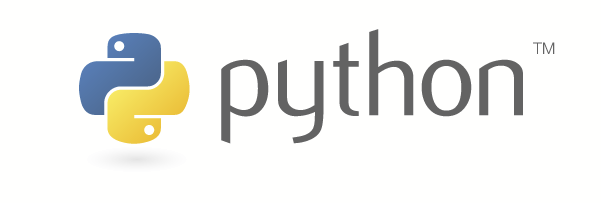
Fredrik Skärberg

In [207]:
import torch #modulen för att skapa neurala nätverk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Dagens agenda

* Frågor kring laboration 2.
* Introduktion till matematiken bakom neurala nätverk
* Hur man implementerar neurala nätverk i `python`
* Icke-linjära neural nätverk
* Applicering på bilder (MNIST-dataset)
* Genomgång av laboration 3
* Frågor

# Artificiella neurala nät
Har de senaste 10+ åren skapat en revolution i vad vi kan göra med maskininlärning.

# Artificiella neurala nät
Ett sätt att bygga upp en funktion så att den kan lära sig från data. De flesta funktioner som modelleras med hjälp av ANN är av typen 
$$f: \mathbb{R}^n \rightarrow \mathbb{R}^k $$
Med andra ord så tar sådana funktioner som indata ett eller flera tal och ger tillbaka ett eller flera tal.
![ANN](../images/neural_net.svg.png)

## Artificiell neuron - byggsten i neurala nät
$$ \mathbb{R}^n \longrightarrow \mathbb{R} $$
$$ y(x_1, x_2, \cdots, x_n) = f\left( \sum_i w_i x_i + b \right) $$
$$ = f\left( w_1 x_1 + w_2 x_2 + ... + b \right) $$

- $w_i$ kallas **weights** eller **vikter**
- $b$ kallas **bias**.
- $f$ kallas **activation function** eller **aktiveringsfunktion**

![test](../images/artificial_neuron.png)



# Exempel på artificiell neuron
Låt oss skapa en artificiell neuron
$$ y(x) = w \cdot x + b $$
Notera att aktiveringsfunktionen här är identitetsfunktionen $f(x) = x$.

In [208]:
# Skapa en neuron som ovan med ett tal som indata och ett tal som utdata
neuron = torch.nn.Linear(1,1)

# Välj vikt och bias så att neuronen motsvarar funktionen y(x) = 2 * x + 5
# Uppdatera vikten och biasen utan att beräkna gradienter
with torch.no_grad():
    neuron.weight[0] = 2.0
    neuron.bias[0] = 5.0
# Evaluera neuronen på talet 1
result = neuron(torch.tensor([1.0]))
print(result)

tensor([7.], grad_fn=<AddBackward0>)


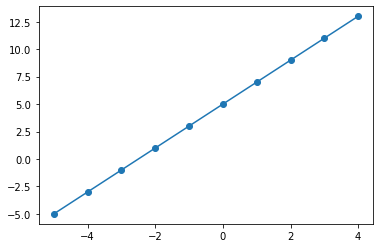

In [209]:
xs = np.arange(-5., 5.)
ys = []

for x in xs:
    x_tensor = torch.tensor([x]).float()
    y_tensor = neuron(x_tensor)
    ys.append(y_tensor[0])

plt.plot(xs, ys, '-o')
plt.show()

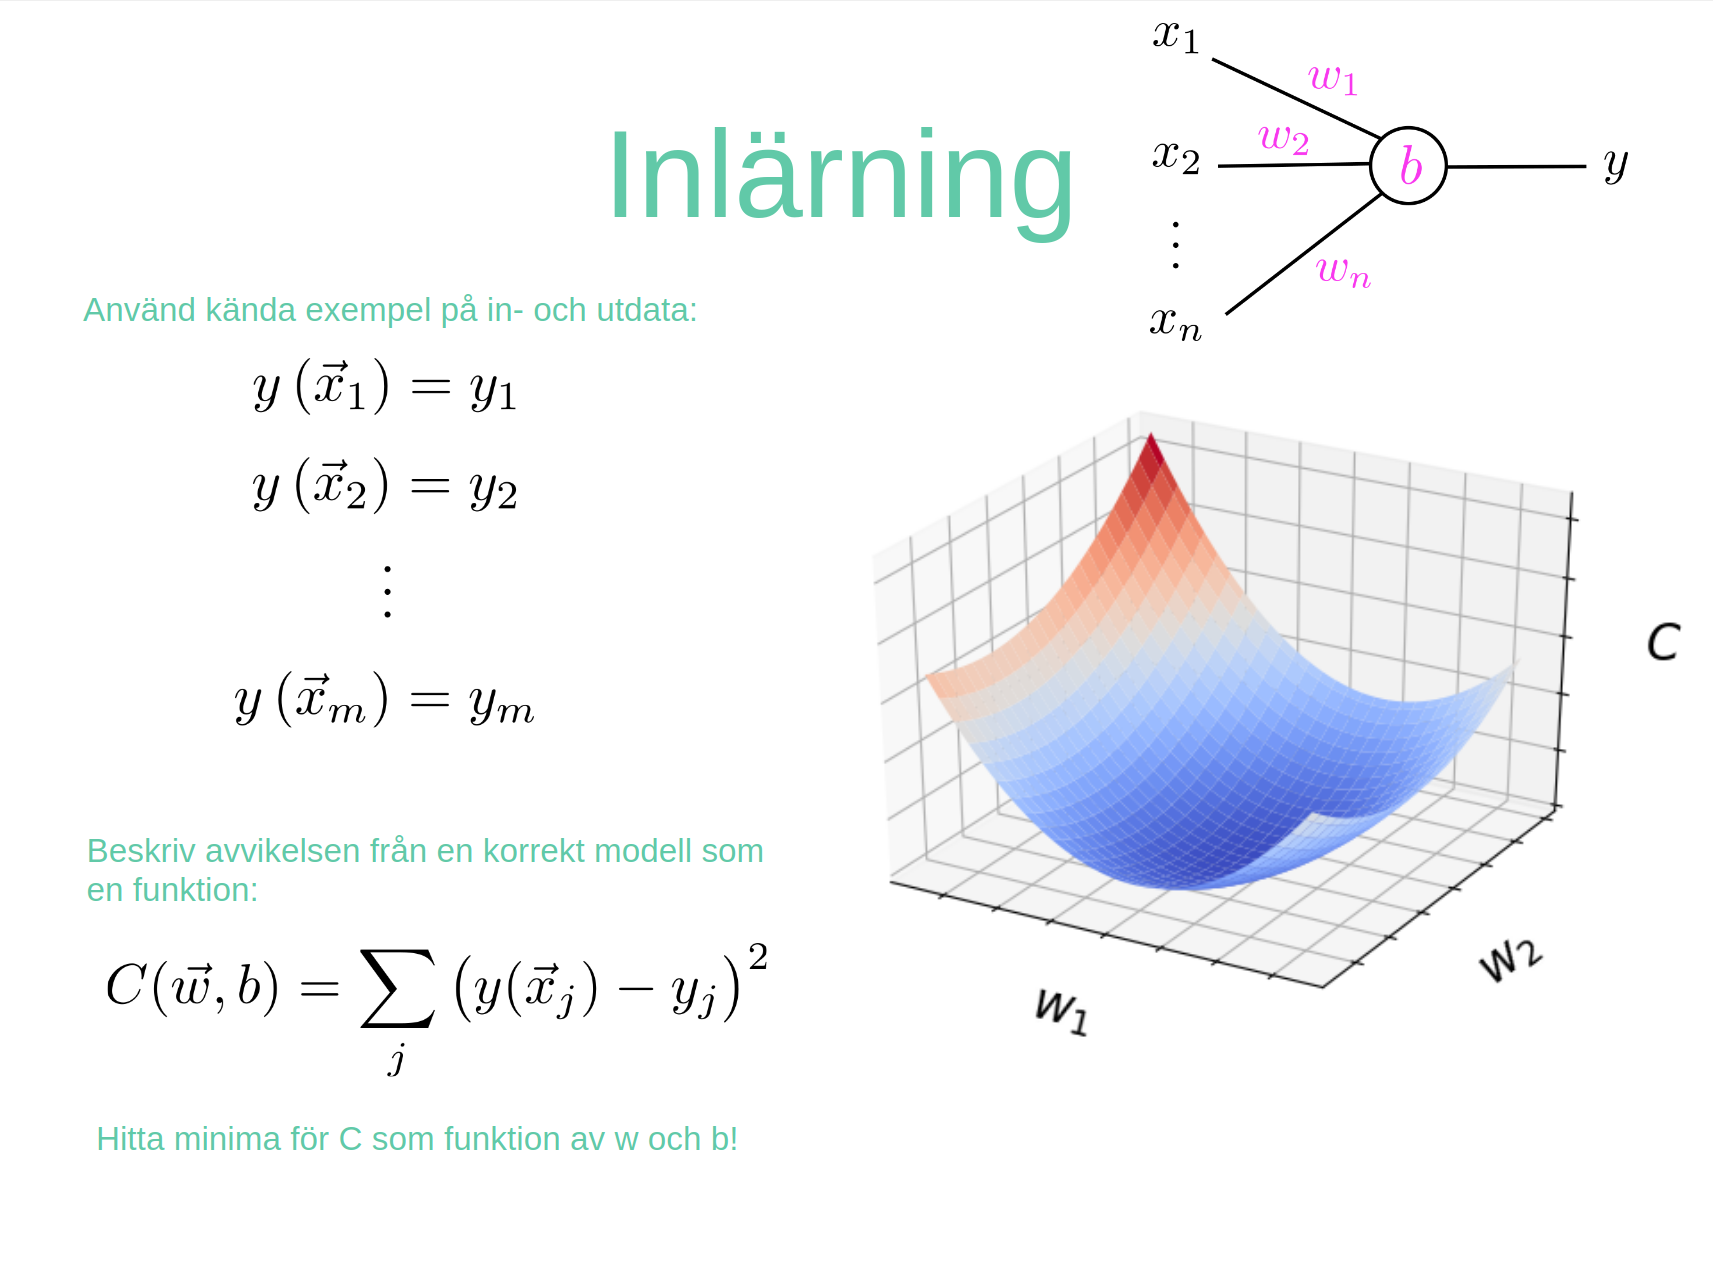

![SGD](../images/sgd2.png)

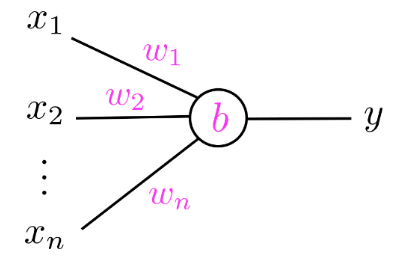

$$ C(w) = \big(y(x_1, w) - y_1\big)^2 + \big(y(x_2, w) - y_2\big)^2 + \ldots$$

![SGD](../images/Gradient_descent.gif)

### Låt oss nu gå vidare och se hur vi kan sätta upp en "träning" för ett neuralt nätverk.

Text(0, 0.5, 'y')

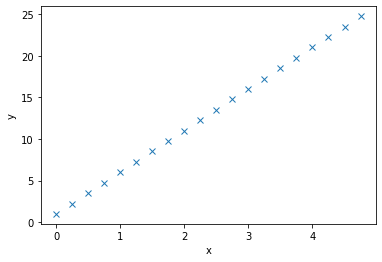

In [210]:
# Funktion som vi vill efterlikna med en neuron. Notera; helt brusfri.
def f(x):
    return 5*x + 1

# Skapa en lista med x och f(x) för funktionen f
xdata = np.arange(0, 5, 0.25) # Tal från 0 till 5 med mellanrum 0.25
ydata = [f(x) for x in xdata]

plt.plot(xdata, ydata, 'x')
plt.xlabel("x")
plt.ylabel("y")

### Träningsloop - hur kan vi istället optimera våra vikter och biaser till datan?

In [211]:
#Vår modell
model = torch.nn.Linear(1,1)

#En optimerare. SGD står för stochastic gradient descent.
optimerare = torch.optim.SGD(model.parameters(), lr=0.001)
epoker = 500
fel_per_epok = []

#Träningsloop
for omgång in range(epoker):
    totalt_fel = 0.0
    
    # Gå igenom all data
    for x, ytarget in zip(xdata, ydata): 
        
        # Konvertera värdet till en torch tensor
        xtensor = torch.Tensor([x])
        
        # Evaluera modellen på talet
        y = model(xtensor)
        
        # Beräkna felet
        fel = abs(y - ytarget)
        
        # Summera felet för kontroll
        totalt_fel += float(fel)
        
        # Nollställ gradienter för optimerare
        optimerare.zero_grad()    
        
        # Beräkna gradienter från felet
        fel.backward()
        
        # Uppdatera gradienterna ett litet steg mot en bättre lösning
        optimerare.step()
        
    #Spara felet för att plotta
    fel_per_epok.append(totalt_fel)
        
    if omgång % 50 == 0:    
        print("Omgång ", omgång, ", fel: ", float(totalt_fel))
    

Omgång  0 , fel:  244.30315124988556
Omgång  50 , fel:  111.6064977645874
Omgång  100 , fel:  5.783600449562073
Omgång  150 , fel:  2.621996760368347
Omgång  200 , fel:  0.08718645572662354
Omgång  250 , fel:  0.08718645572662354
Omgång  300 , fel:  0.08718645572662354
Omgång  350 , fel:  0.08718645572662354
Omgång  400 , fel:  0.08718645572662354
Omgång  450 , fel:  0.08718645572662354


Text(0, 0.5, 'Fel')

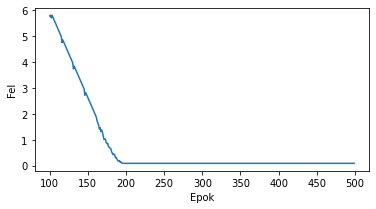

In [212]:
#Se att felet minskar desto längre vi tränar
k=100
plt.figure(figsize = (6, 3))
plt.plot(np.arange(k, len(fel_per_epok)), fel_per_epok[k:])
plt.xlabel('Epok')
plt.ylabel('Fel')

k =  tensor([4.9969], grad_fn=<SelectBackward0>)
a =  tensor(1.0028, grad_fn=<SelectBackward0>)


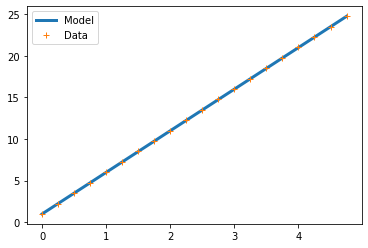

In [213]:
#Vi har lyckats approximera vår funktion.
ymodel = []
for x in xdata:
    xtensor = torch.Tensor([x])
    ymodel.append(float(model(xtensor)))
                  
plt.plot(xdata, ymodel, label="Model", linewidth=3)
plt.plot(xdata, ydata, "+", label="Data")
plt.legend()

print("k = ", model.weight[0])
print("a = ", model.bias[0])

## Data med brus

Låt oss kolla på lite data med brus istället

Text(0, 0.5, 'y')

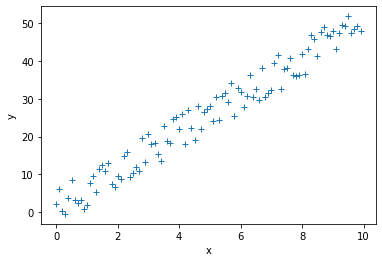

In [215]:
import random

# Funktion som vi vill efterlikna med en neuron
def f(x):
    return 5*x + 1

# Skapa en lista med x och f(x) för funktionen f
xdata = numpy.arange(0, 10, 0.1)
ydata = [f(x) + random.uniform(-5, 5) for x in xdata]

plt.plot(xdata, ydata, '+')
plt.xlabel("x")
plt.ylabel("y")

In [216]:
model = torch.nn.Linear(1,1)

#En optimerare. SGD står för stochastic gradient descent.
optimerare = torch.optim.SGD(model.parameters(), lr=0.001)

epoker = 100
fel_per_epok = []

for omgång in range(epoker):
    totalt_fel = 0.0
    
    # Gå igenom all data
    for x, ytarget in zip(xdata, ydata):
        # Konvertera värdet till en torch tensor
        xtensor = torch.Tensor([x])
        
        # Evaluera modellen på talet
        y = model(xtensor)
        
        # Beräkna felet
        fel = (y - ytarget)**2
        
        # Summera felet för kontroll
        totalt_fel += float(fel)
        
        # Nollställ gradienter för optimerare
        optimerare.zero_grad()    
        
        # Beräkna gradienter från felet
        fel.backward()
        
        # Uppdatera gradienterna ett litet steg mot en bättre lösning
        optimerare.step()
    fel_per_epok.append(totalt_fel)
    
    if omgång % 10 == 0:    
        print("Omgång ", omgång, ", fel: ", float(totalt_fel))

Omgång  0 , fel:  6347.152195921168
Omgång  10 , fel:  1010.4728930783458
Omgång  20 , fel:  1006.4763479784015
Omgång  30 , fel:  1004.8864707133616
Omgång  40 , fel:  1004.280197981745
Omgång  50 , fel:  1004.0672358835582
Omgång  60 , fel:  1004.0055766077712
Omgång  70 , fel:  1003.9982094436418
Omgång  80 , fel:  1004.0070768792648
Omgång  90 , fel:  1004.0184255291242


Text(0, 0.5, 'Fel')

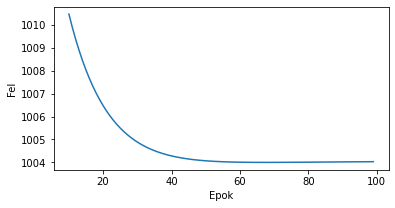

In [218]:
#Se att felet minskar desto längre vi tränar
k=10
plt.figure(figsize = (6, 3))
plt.plot(np.arange(k, len(fel_per_epok)), fel_per_epok[k:])
plt.xlabel('Epok')
plt.ylabel('Fel')

k =  tensor([4.9560], grad_fn=<SelectBackward0>)
a =  tensor(1.2241, grad_fn=<SelectBackward0>)


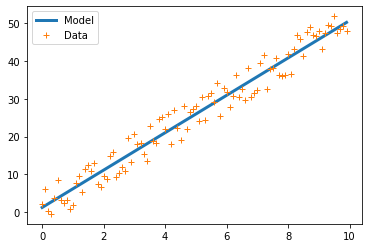

In [220]:
ymodel = []
for x in xdata:
    xtensor = torch.Tensor([x])
    ymodel.append(float(model(xtensor)))
                  
plt.plot(xdata, ymodel, label="Model", linewidth=3)
plt.plot(xdata, ydata, "+", label="Data")
plt.legend()

print("k = ", model.weight[0])
print("a = ", model.bias[0])

Okej, men om vi har något som är icke-linjärt istället?

In [221]:
def träna(xdata, ydata, model, optimerare, epoker=1000):
    
    fel_per_epok = []
    for omgång in range(epoker):
        totalt_fel = 0.0
        for x, ytarget in zip(xdata, ydata): 
            xtensor = torch.Tensor([x])
            y = model(xtensor)
            
            # Beräkna felet
            fel = abs(y - ytarget)
            
            # Summera felet för kontroll
            totalt_fel += float(fel)
            
            # Nollställ gradienter för optimerare
            optimerare.zero_grad()    
            
            # Beräkna gradienter från felet
            fel.backward()
            
            # Uppdatera parametrarna i modellen (dvs w och b) ett litet steg mot en bättre lösning
            # med hjälp av gradienterna
            optimerare.step()
            
        fel_per_epok.append(totalt_fel)
        
        if omgång % 50 == 0:    
            print("Omgång ", omgång, ", fel: ", float(totalt_fel))
    
    print(f"Fel sista epoken: {float(totalt_fel)}")
    
    return fel_per_epok

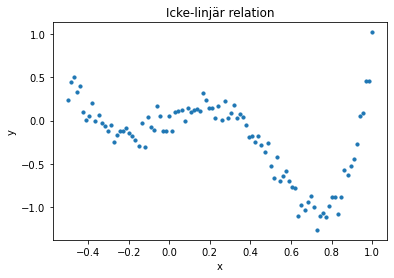

In [222]:
n=100
xdata = np.linspace(-0.5, 1, n)
#En icke-linjär relation. Ett femtegradspolynom
ydata = (xdata**5 - xdata**3 + xdata/10 + np.random.normal(0, 0.01, n))*10
plt.scatter(xdata, ydata, s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Icke-linjär relation')
plt.show()

In [223]:
model = torch.nn.Linear(1,1) # Skapa en linjär modell med en indata och en utdata
optimerare = torch.optim.SGD(model.parameters(), lr=0.01)

epoker = 500

#Träna modellen
fel_per_epok = träna(xdata, ydata, model, optimerare, epoker)

Omgång  0 , fel:  62.68945740535855
Omgång  50 , fel:  28.01451124995947
Omgång  100 , fel:  28.015447914600372
Omgång  150 , fel:  28.070638343691826
Omgång  200 , fel:  28.07074861228466
Omgång  250 , fel:  28.070858880877495
Omgång  300 , fel:  28.07096926122904
Omgång  350 , fel:  28.07107887417078
Omgång  400 , fel:  28.056678257882595
Omgång  450 , fel:  28.05596201121807
Fel sista epoken: 27.66673508286476


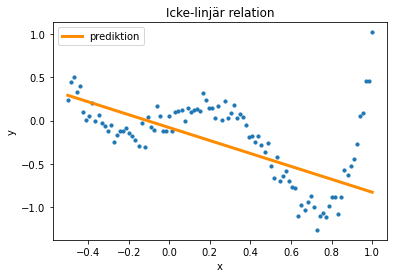

In [224]:
ymodel = []
for x in xdata:
    xtensor = torch.Tensor([x])
    ymodel.append(float(model(xtensor)))

plt.scatter(xdata, ydata, s=10)
plt.plot(xdata, ymodel, color='darkorange', linewidth=3, label='prediktion')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Icke-linjär relation')
plt.show()

## Bygga icke-linjära nätverk

För att kunna anpassa till den nya funktionen behöver vi uppdatera modellen.

In- och utdata är fortfarande ett tal så vi måste börja med en neuron som tar in ett tal och sluta med en neuron, men däremellan kan nätverket se väldigt olika ut.

Hur kan olika neurala nät se ut som tar in ett tal och ger tillbaka ett tal som utdata? Nedan är några exempel 

Notera att till vänster är Python kod för att skapa modellen där `torch.nn` är borttaget, så t.ex för att skapa andra exemplet så behöver du skriva `torch.nn.Sequential( torch.nn.Linear(1,1), torch.nn.Linear(1,1))`.

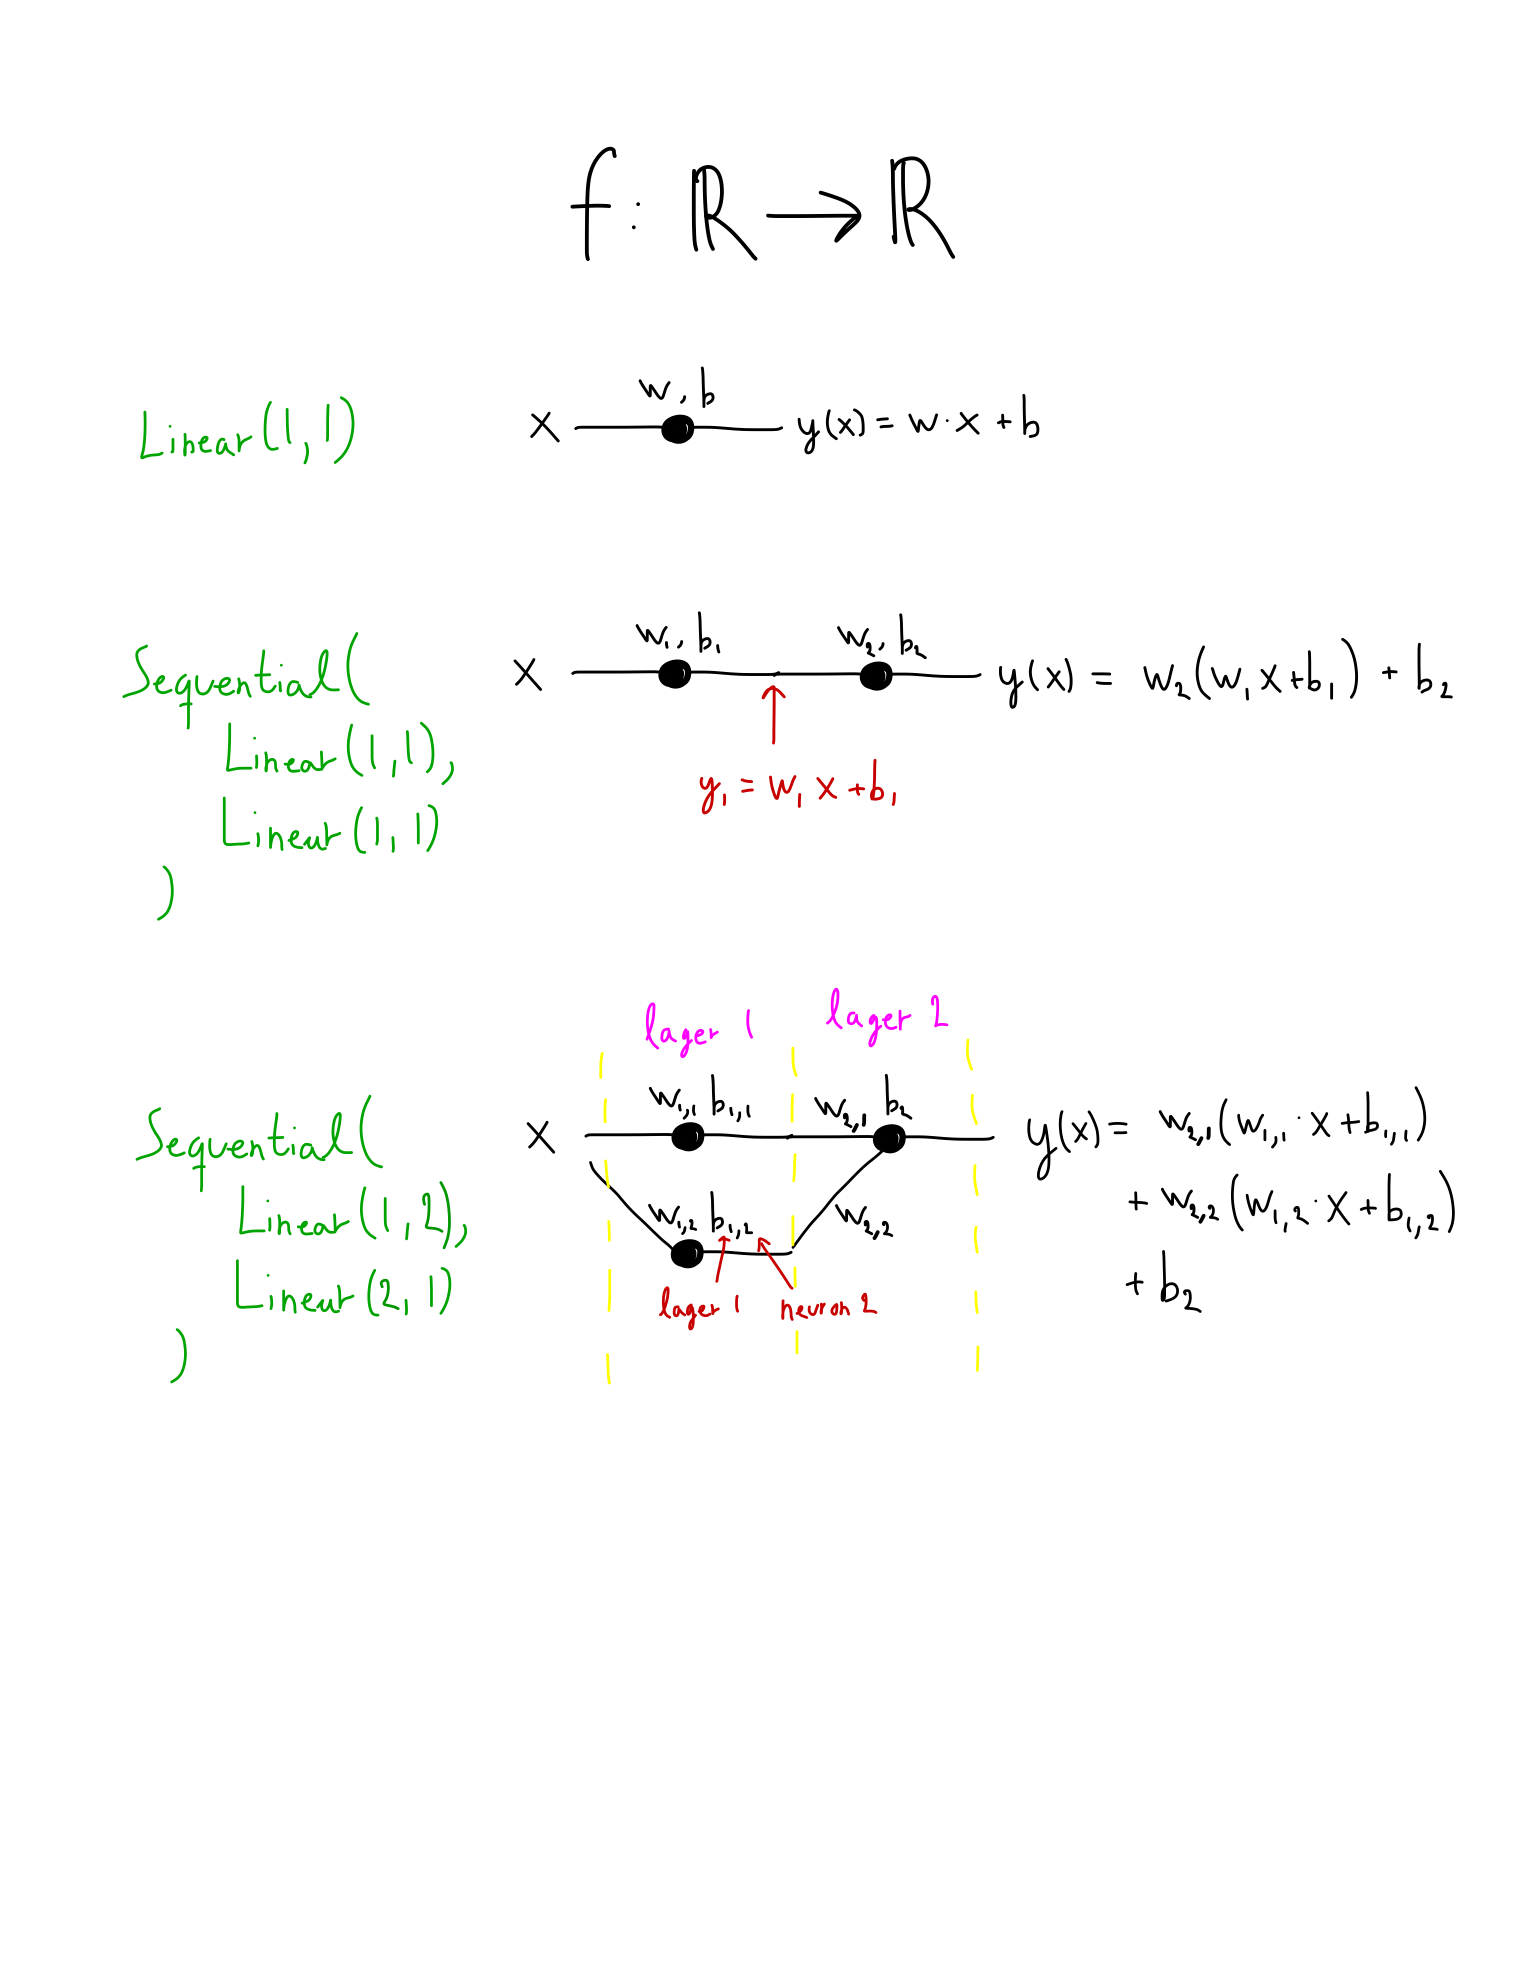

I alla dessa exempel så beskriver hela nätverket tillsammans alltid en linjär funktion, dvs hela nätverket kan beskrivas som $y(x) = w * x + b$. 

För att kunna skapa något icke-linjärt behöver vi introducera aktiveringsfunktioner. En enkel, men även extremt användbar sådan, är 
$$ 
\text{ReLU}(x) = \begin{cases}
x & x > 0 \\
0 & x \leq 0
\end{cases}
$$

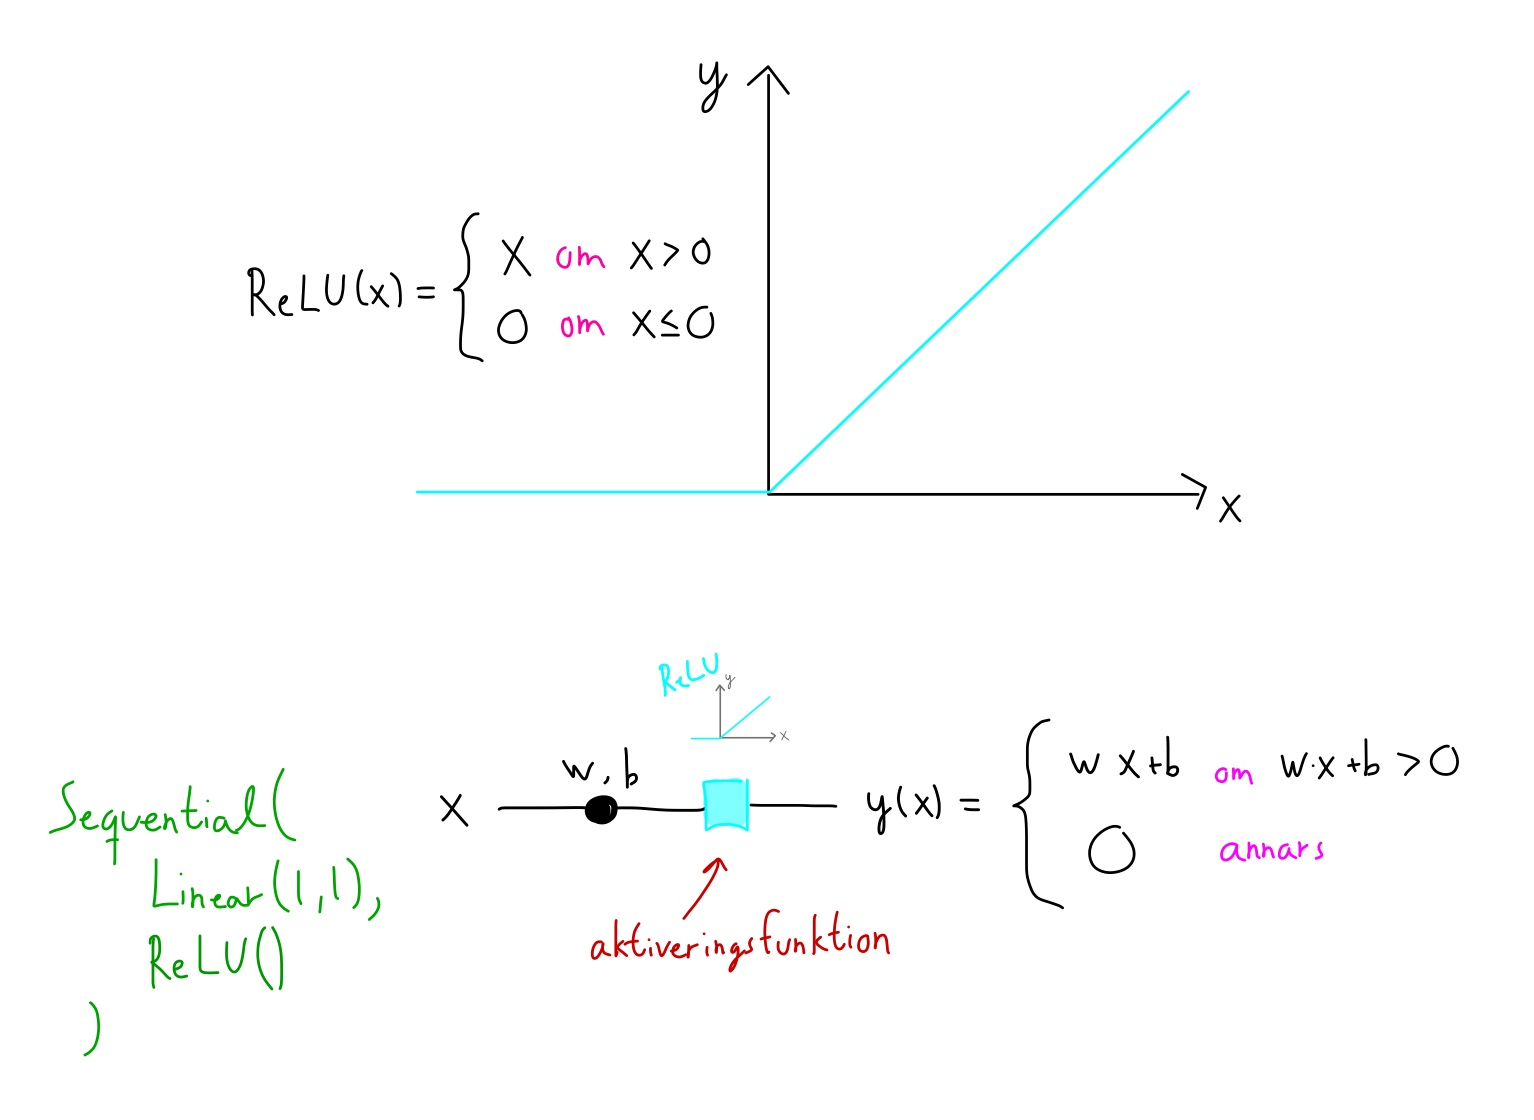

Genom att lägga till en aktiveringsfunktion efter varje neuron så kan vi beskriva mycket mer komplicerade funktioner!
T.ex kan det se ut som

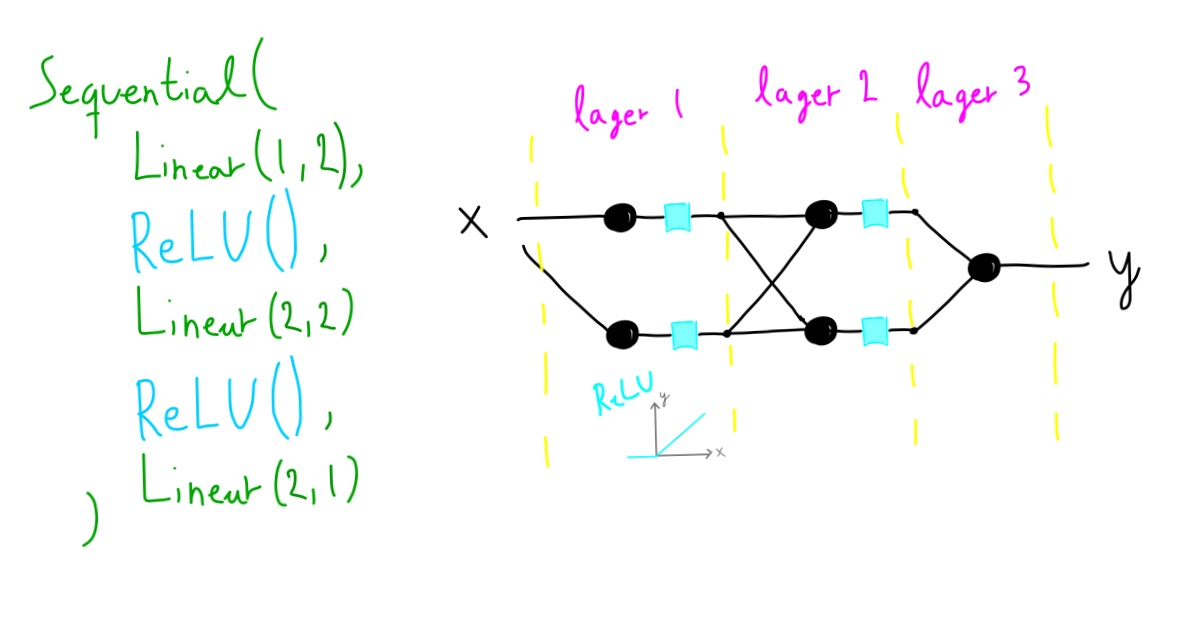

Så låt oss implementera det neurala nätverket ovan!

In [225]:
model = torch.nn.Sequential(
    torch.nn.Linear(1,2), 
    torch.nn.ReLU(), 
    torch.nn.Linear(2,2), 
    torch.nn.ReLU(), 
    torch.nn.Linear(2,1)
    )

In [226]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 13


In [227]:
optimerare = torch.optim.SGD(model.parameters(), lr=0.0025)

#Träna modellen
fel_per_epok = träna(xdata, ydata, model, optimerare, epoker=epoker)

Omgång  0 , fel:  68.00397962331772
Omgång  50 , fel:  34.10746954753995
Omgång  100 , fel:  28.931653382256627
Omgång  150 , fel:  20.955686017870903
Omgång  200 , fel:  19.60490375570953
Omgång  250 , fel:  19.65395975857973
Omgång  300 , fel:  19.87827681750059
Omgång  350 , fel:  19.881809283047915
Omgång  400 , fel:  19.626490082591772
Omgång  450 , fel:  19.612486761063337
Fel sista epoken: 19.618656903505325


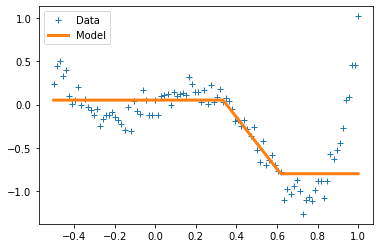

In [228]:
ymodel = []
for x in xdata:
    xtensor = torch.Tensor([x])
    ymodel.append(float(model(xtensor)))
                  
plt.plot(xdata, ydata, "+", label="Data")
plt.plot(xdata, ymodel, label="Model", linewidth=3)
plt.legend()

Okej, kanske inte helt optimalt? Vi kan till exempel ändra vår model genom att ändra:
* Antalet neuroner
* Antalet lager
* Aktiveringsfunktion
* Inlärningshastighet
* Antalet epoker

In [229]:
N = 16
#4 lager, varav 2st "gömda" med 16 neuroner.
model = torch.nn.Sequential(
    torch.nn.Linear(1,N), 
    torch.nn.ReLU(), 
    torch.nn.Linear(N,N), 
    torch.nn.ReLU(),
    torch.nn.Linear(N,N), 
    torch.nn.ReLU(),
    torch.nn.Linear(N,1)
    )

In [230]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 593


In [231]:
optimerare = torch.optim.SGD(model.parameters(), lr=0.0025)

#Träna modellen
fel_per_epok = träna(xdata, ydata, model, optimerare, epoker=epoker)

Omgång  0 , fel:  35.23712282255292
Omgång  50 , fel:  24.2766529135406
Omgång  100 , fel:  20.90105826407671
Omgång  150 , fel:  17.063962457701564
Omgång  200 , fel:  12.633371140807867
Omgång  250 , fel:  11.455468129366636
Omgång  300 , fel:  11.686350163072348
Omgång  350 , fel:  11.418284576386213
Omgång  400 , fel:  10.823390383273363
Omgång  450 , fel:  11.385327342897654
Fel sista epoken: 10.945558447390795


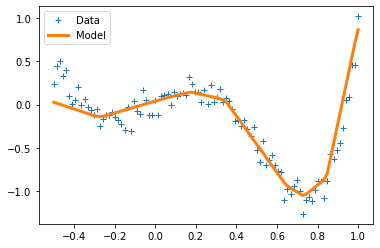

In [232]:
ymodel = []
for x in xdata:
    xtensor = torch.Tensor([x])
    ymodel.append(float(model(xtensor)))
                  
plt.plot(xdata, ydata, "+", label="Data")
plt.plot(xdata, ymodel, label="Model", linewidth=3)
plt.legend()

Verkar funka helt okej med ReLU i detta fallet, men låt oss testa en annan aktiveringsfunktion!

En annan användbar aktiveringsfunktion är
$$ \tanh(x) $$

Text(0.5, 1.0, 'tanh(x) intervall = (-5, 5)')

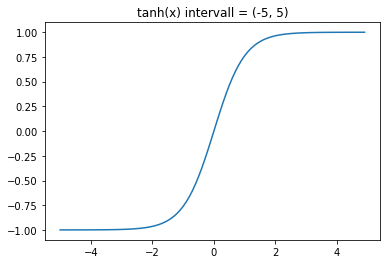

In [233]:
#Definition av tanh
def tanh(x):
    return (torch.exp(x) - torch.exp(-x))/(torch.exp(x) + torch.exp(-x))

x = numpy.arange(-5, 5, 0.1)
y = numpy.tanh(x)
plt.plot(x, y)
plt.title("tanh(x) intervall = (-5, 5)")

In [238]:
N = 16
#4 lager, varav 2st "gömda" med 16 neuroner.
model = torch.nn.Sequential(
    torch.nn.Linear(1,N), 
    torch.nn.Tanh(), 
    torch.nn.Linear(N,N), 
    torch.nn.Tanh(),
    torch.nn.Linear(N,N), 
    torch.nn.Tanh(),
    torch.nn.Linear(N,1)
    )

In [239]:
optimerare = torch.optim.SGD(model.parameters(), lr=0.0025)

#Träna modellen
fel_per_epok = träna(xdata, ydata, model, optimerare, epoker=epoker)

AttributeError: module 'torch.optim' has no attribute 'ADAM'

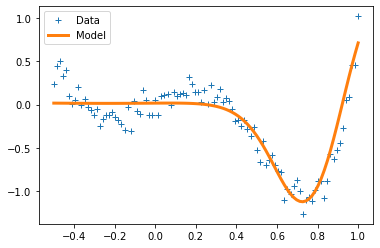

In [236]:
ymodel = []
for x in xdata:
    xtensor = torch.Tensor([x])
    ymodel.append(float(model(xtensor)))
                  
plt.plot(xdata, ydata, "+", label="Data")
plt.plot(xdata, ymodel, label="Model", linewidth=3)
plt.legend()

In [237]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 593
